In [27]:
# Importación de librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import holidays

In [3]:
# Definir rutas relativas desde la carpeta notebooks
path_competencia = '../data/raw/entrenamiento/competencia.csv'
path_ventas = '../data/raw/entrenamiento/ventas.csv'

# Cargar los archivos CSV
competencia_df = pd.read_csv(path_competencia)
ventas_df = pd.read_csv(path_ventas)

# Mostrar las primeras filas para verificar
competencia_df.head(), ventas_df.head()

(        fecha producto_id  Amazon  Decathlon  Deporvillage
 0  2021-10-25    PROD_001   82.96     111.88         97.43
 1  2021-10-25    PROD_002  112.56     108.61        115.58
 2  2021-10-25    PROD_003   79.79      78.44         80.11
 3  2021-10-25    PROD_004   72.60      67.29         74.45
 4  2021-10-25    PROD_005   37.71      33.60         33.07,
         fecha producto_id                            nombre categoria  \
 0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
 1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
 2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
 3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
 4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   
 
          subcategoria  precio_base  es_estrella  unidades_vendidas  \
 0  Zapatillas Running          115         True                  6   
 1  Zapatillas Running          135         True   

In [4]:
# Validación de la calidad de datos de ventas_df
print('--- Tipos de variables ---')
print(ventas_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(ventas_df.isnull().sum())
print('\n--- Porcentaje de valores nulos por columna ---')
print((ventas_df.isnull().mean() * 100).round(2))
print('\n--- Estadísticas descriptivas (numéricas) ---')
print(ventas_df.describe())
print('\n--- Estadísticas descriptivas (categóricas) ---')
print(ventas_df.describe(include=["object", "category"]))
print('\n--- Valores únicos por columna ---')
print(ventas_df.nunique())

# Informe final de calidad de datos
from pandas.api.types import is_numeric_dtype, is_object_dtype

informe = []
for col in ventas_df.columns:
    col_info = {
        'columna': col,
        'tipo': ventas_df[col].dtype,
        'nulos': ventas_df[col].isnull().sum(),
        'nulos_%': round(ventas_df[col].isnull().mean() * 100, 2),
        'únicos': ventas_df[col].nunique()
    }
    if is_numeric_dtype(ventas_df[col]):
        col_info['min'] = ventas_df[col].min()
        col_info['max'] = ventas_df[col].max()
        col_info['media'] = ventas_df[col].mean()
        col_info['desv_std'] = ventas_df[col].std()
    elif is_object_dtype(ventas_df[col]):
        col_info['más_frecuente'] = ventas_df[col].mode().iloc[0] if not ventas_df[col].mode().empty else None
    informe.append(col_info)

informe_df = pd.DataFrame(informe)
print('\n--- Informe final de calidad de datos ---')
display(informe_df)

--- Tipos de variables ---
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- Valores nulos por columna ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- Porcentaje de valores nulos por columna ---
fecha                0.0
producto_id          0.0
nombre               0.0
categoria            0.0
subcategoria         0.0
precio_base          0.0
es_estrella          0.0
unidades_vendidas    0.0
precio_venta         0.0
ingresos             0.0
dtype: float64

--- Estadísticas descriptivas (numéricas) ---
       precio_base  unidades_v

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\3746438669.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(ventas_df.describe(include=["object", "category"]))


,columna,tipo,nulos,nulos_%,únicos,min,max,media,desv_std
0,fecha,str,0,0.0,148,NaN,NaN,NaN,NaN
1,producto_id,str,0,0.0,24,NaN,NaN,NaN,NaN
2,nombre,str,0,0.0,24,NaN,NaN,NaN,NaN
3,categoria,str,0,0.0,4,NaN,NaN,NaN,NaN
4,subcategoria,str,0,0.0,16,NaN,NaN,NaN,NaN
5,precio_base,int64,0,0.0,21,20,830,123.125000,165.576753
6,es_estrella,bool,0,0.0,2,False,True,0.291667,0.454594
7,unidades_vendidas,int64,0,0.0,52,1,85,4.878660,6.311020
8,precio_venta,float64,0,0.0,2537,19.0,854.22,121.816546,164.017963
9,ingresos,float64,0,0.0,3033,19.46,14508.4,605.972323,1079.071192


In [5]:
# Validación de la calidad de datos de competencia_df
print('--- Tipos de variables ---')
print(competencia_df.dtypes)
print('\n--- Valores nulos por columna ---')
print(competencia_df.isnull().sum())
print('\n--- Porcentaje de valores nulos por columna ---')
print((competencia_df.isnull().mean() * 100).round(2))
print('\n--- Estadísticas descriptivas (numéricas) ---')
print(competencia_df.describe())
print('\n--- Estadísticas descriptivas (categóricas) ---')
print(competencia_df.describe(include=["object", "category"]))
print('\n--- Valores únicos por columna ---')
print(competencia_df.nunique())

# Informe final de calidad de datos
from pandas.api.types import is_numeric_dtype, is_object_dtype

informe_comp = []
for col in competencia_df.columns:
    col_info = {
        'columna': col,
        'tipo': competencia_df[col].dtype,
        'nulos': competencia_df[col].isnull().sum(),
        'nulos_%': round(competencia_df[col].isnull().mean() * 100, 2),
        'únicos': competencia_df[col].nunique()
    }
    if is_numeric_dtype(competencia_df[col]):
        col_info['min'] = competencia_df[col].min()
        col_info['max'] = competencia_df[col].max()
        col_info['media'] = competencia_df[col].mean()
        col_info['desv_std'] = competencia_df[col].std()
    elif is_object_dtype(competencia_df[col]):
        col_info['más_frecuente'] = competencia_df[col].mode().iloc[0] if not competencia_df[col].mode().empty else None
    informe_comp.append(col_info)

informe_comp_df = pd.DataFrame(informe_comp)
print('\n--- Informe final de calidad de datos (competencia_df) ---')
display(informe_comp_df)

--- Tipos de variables ---
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- Valores nulos por columna ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- Porcentaje de valores nulos por columna ---
fecha           0.0
producto_id     0.0
Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

--- Estadísticas descriptivas (numéricas) ---
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000

--- Estadísticas descriptivas (categóricas) ---
             fecha producto

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\846140921.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(competencia_df.describe(include=["object", "category"]))


,columna,tipo,nulos,nulos_%,únicos,min,max,media,desv_std
0,fecha,str,0,0.0,148,NaN,NaN,NaN,NaN
1,producto_id,str,0,0.0,24,NaN,NaN,NaN,NaN
2,Amazon,float64,0,0.0,3125,16.85,858.3500,118.623407,156.095628
3,Decathlon,float64,0,0.0,3001,15.45,867.3375,111.412182,148.508132
4,Deporvillage,float64,0,0.0,3105,16.77,932.3250,118.894628,160.216448


In [6]:
# Convertir la columna 'fecha' a tipo datetime en ambos dataframes
ventas_df['fecha'] = pd.to_datetime(ventas_df['fecha'])
competencia_df['fecha'] = pd.to_datetime(competencia_df['fecha'])

# Verificar la conversión
display(ventas_df['fecha'].head())
display(competencia_df['fecha'].head())

0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[us]

0   2021-10-25
1   2021-10-25
2   2021-10-25
3   2021-10-25
4   2021-10-25
Name: fecha, dtype: datetime64[us]

In [7]:
ventas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB


In [8]:
competencia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 166.6 KB


In [9]:
# Integrar los datos de competencia_df y ventas_df en un nuevo dataframe df
# Usando 'fecha' y 'producto_id' como claves de unión

df = pd.merge(ventas_df, competencia_df, on=['fecha', 'producto_id'], how='inner')

# Mostrar las primeras filas del dataframe integrado
display(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


## Análisis exploratorio completo de `df`
A continuación se presentan diferentes análisis y visualizaciones exploratorias utilizando Seaborn para el DataFrame `df`. Cada análisis se encuentra en una celda separada para facilitar la interpretación y reutilización.

In [10]:
# 1. Información general y primeras filas
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(5), int64(2), str(4)
memory usage: 

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


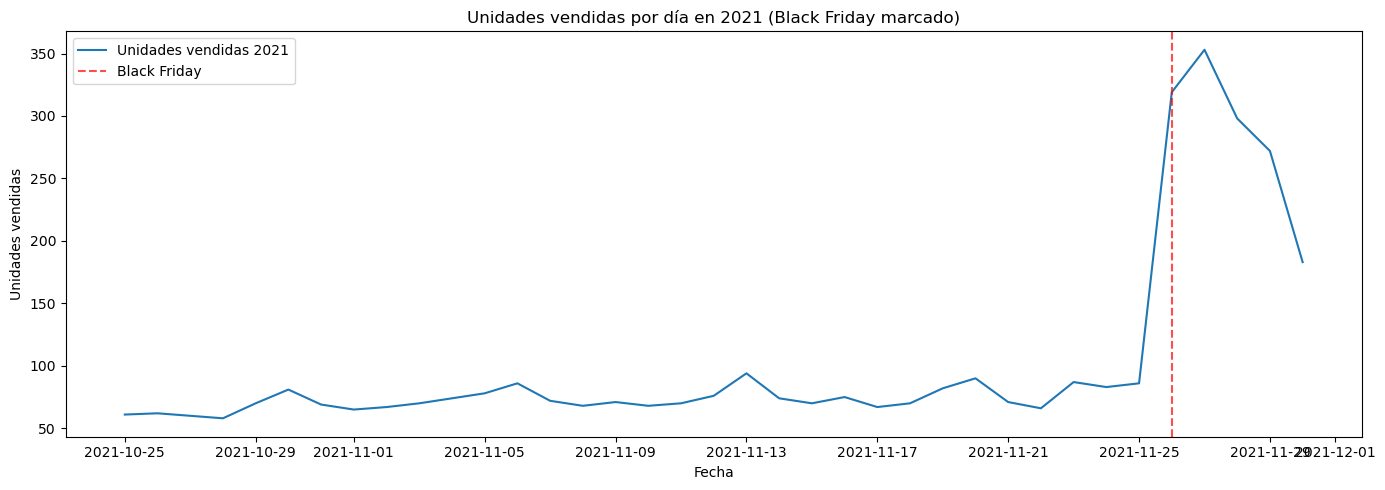

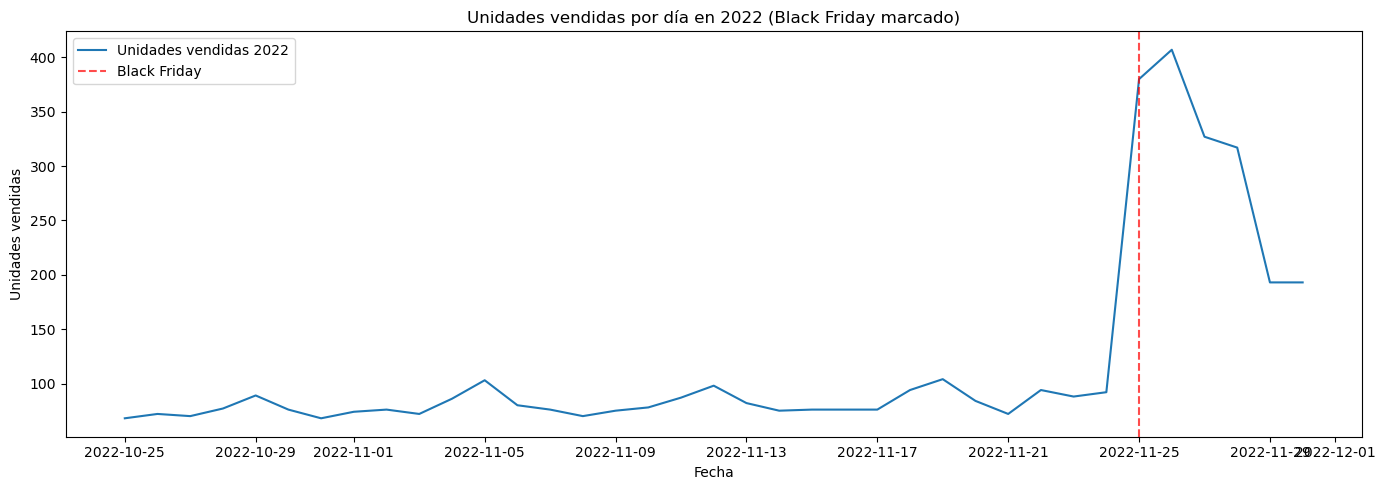

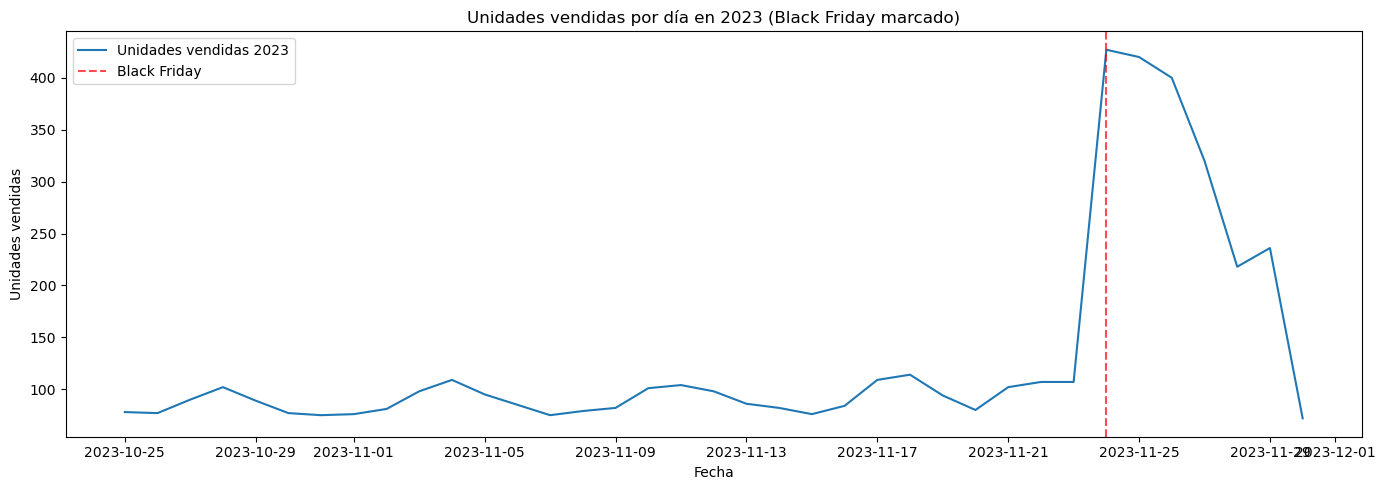

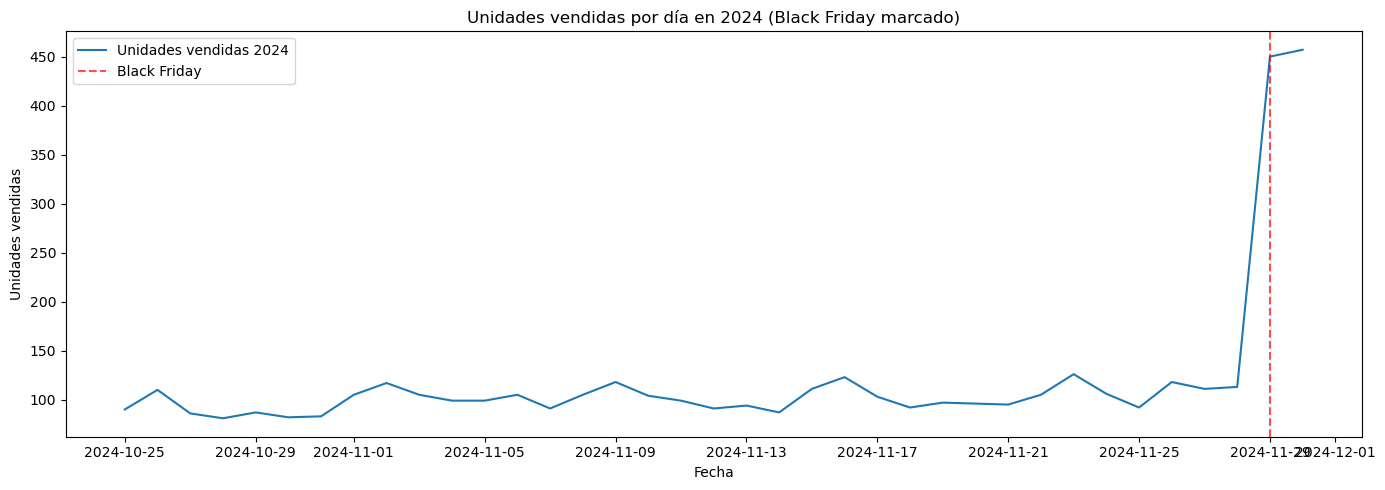

In [11]:
# 2. Gráfico de línea temporal por año con suma de unidades vendidas y Black Friday
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Asegurarse de que la columna de fecha esté en formato datetime
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year

# Identificar Black Friday (asumiendo que hay una columna o lógica para identificarlo)
# Si hay una columna 'black_friday' booleana, si no, se puede definir por fecha (último viernes de noviembre)
def is_black_friday(date):
    # Black Friday: último viernes de noviembre
    year = date.year
    november = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = november[november.weekday == 4]
    if len(fridays) > 0 and date in fridays and date == fridays[-1]:
        return True
    return False

if 'black_friday' not in df.columns:
    df['black_friday'] = df['fecha'].apply(is_black_friday)

for year in sorted(df['año'].unique()):
    plt.figure(figsize=(14, 5))
    data_year = df[df['año'] == year]
    daily = data_year.groupby('fecha')['unidades_vendidas'].sum().reset_index()
    sns.lineplot(data=daily, x='fecha', y='unidades_vendidas', label=f'Unidades vendidas {year}')
    # Marcar Black Friday
    bf_dates = data_year[data_year['black_friday']]['fecha'].unique()
    for i, bf in enumerate(bf_dates):
        plt.axvline(bf, color='red', linestyle='--', alpha=0.7, label='Black Friday' if i == 0 else None)
    plt.title(f'Unidades vendidas por día en {year} (Black Friday marcado)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\3730771021.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\augus\AppData\Local\Temp\ipykernel_16356\3730771021.py:11: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


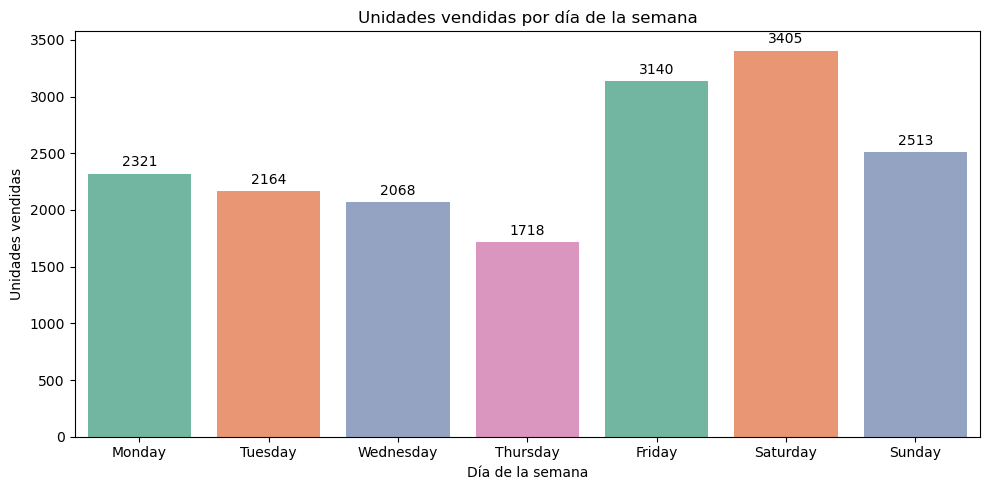

In [14]:
# 3. Suma de unidades vendidas por día de la semana (con etiquetas en barras)
# Definir la paleta de colores como en la celda de categorías
palette = sns.color_palette("Set2", df['categoria'].nunique())

df['dia_semana'] = df['fecha'].dt.day_name(locale='en_US') if hasattr(df['fecha'].dt, 'day_name') else df['fecha'].dt.dayofweek

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex(orden_dias, fill_value=0).reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=ventas_dia,
    x='dia_semana',
    y='unidades_vendidas',
    order=orden_dias,
    palette=palette
)

# Etiquetas de datos
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f'{int(h)}',
        (p.get_x() + p.get_width() / 2, h),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.tight_layout()
plt.show()

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\1242688623.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


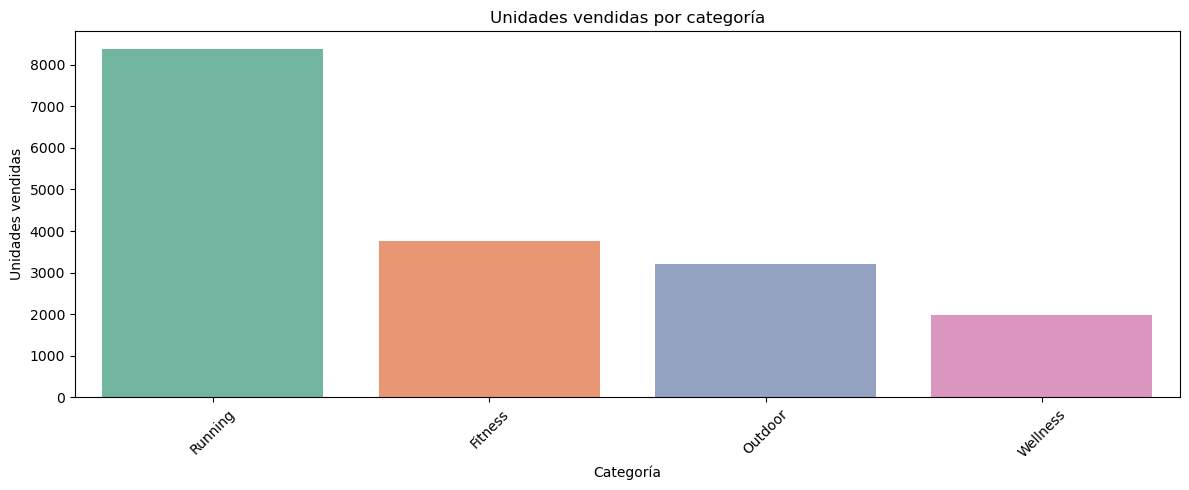

In [15]:
# 4. Suma de unidades vendidas por categoría con barras coloridas
plt.figure(figsize=(12, 5))
palette = sns.color_palette("Set2", df['categoria'].nunique())
sns.barplot(
    data=df.groupby('categoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
    x='categoria', y='unidades_vendidas', palette=palette
)
plt.title('Unidades vendidas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\4140940798.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
C:\Users\augus\AppData\Local\Temp\ipykernel_16356\4140940798.py:3: UserWarning: 
The palette list has fewer values (4) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),


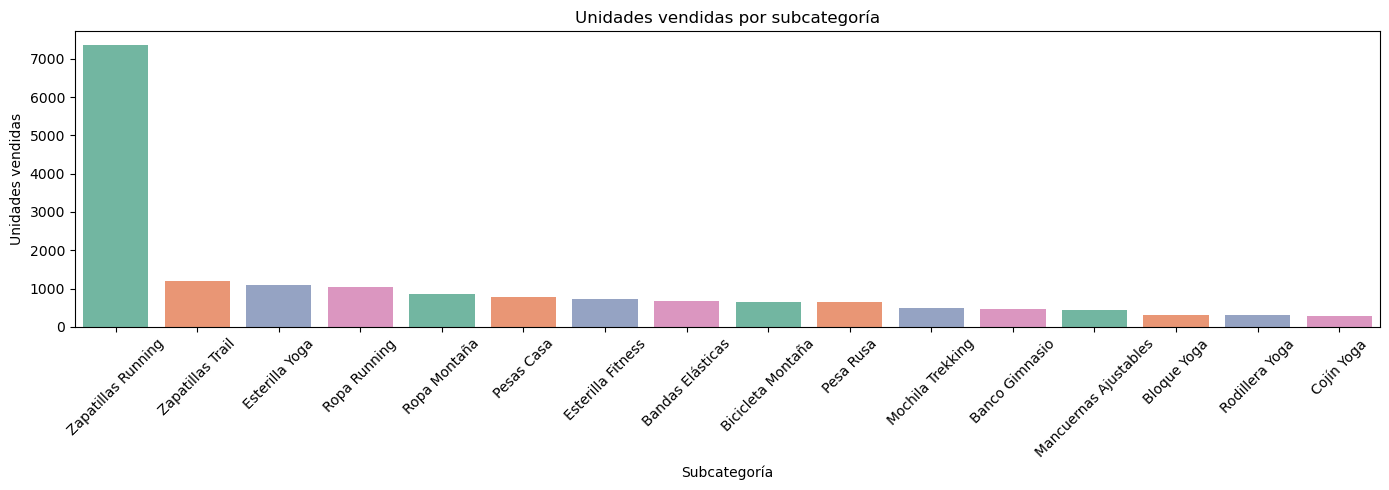

In [16]:
# 5. Suma de unidades vendidas por subcategoría
plt.figure(figsize=(14, 5))
sns.barplot(data=df.groupby('subcategoria')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False),
            x='subcategoria', y='unidades_vendidas', palette=palette)
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\augus\AppData\Local\Temp\ipykernel_16356\2094562948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas', palette=palette)
C:\Users\augus\AppData\Local\Temp\ipykernel_16356\2094562948.py:5: UserWarning: 
The palette list has fewer values (4) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas', palette=palette)


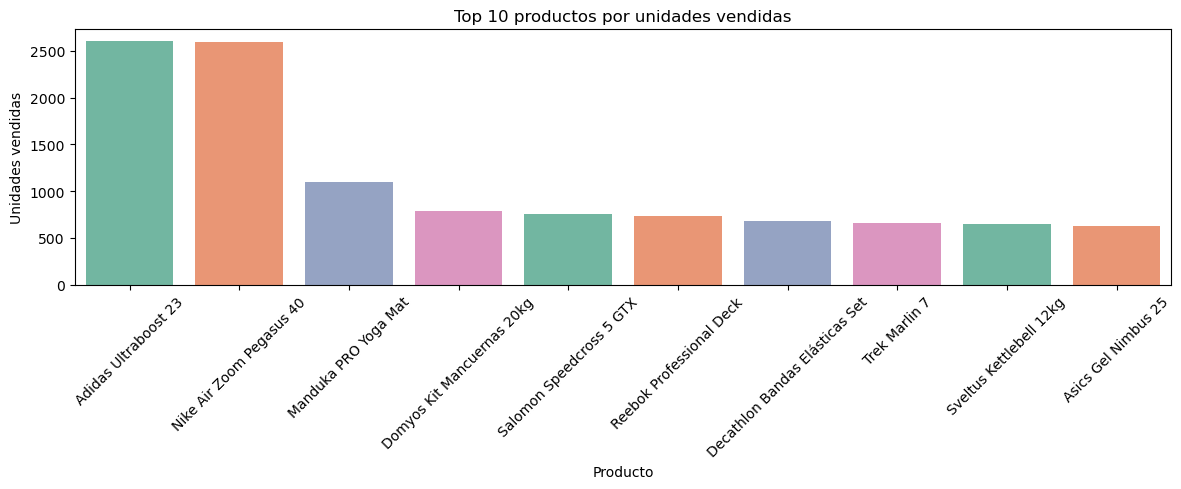

In [17]:
# 6. Suma de unidades vendidas por top productos
TOP_N = 10
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().reset_index().sort_values('unidades_vendidas', ascending=False).head(TOP_N)
plt.figure(figsize=(12, 5))
sns.barplot(data=top_productos, x='nombre', y='unidades_vendidas', palette=palette)
plt.title(f'Top {TOP_N} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

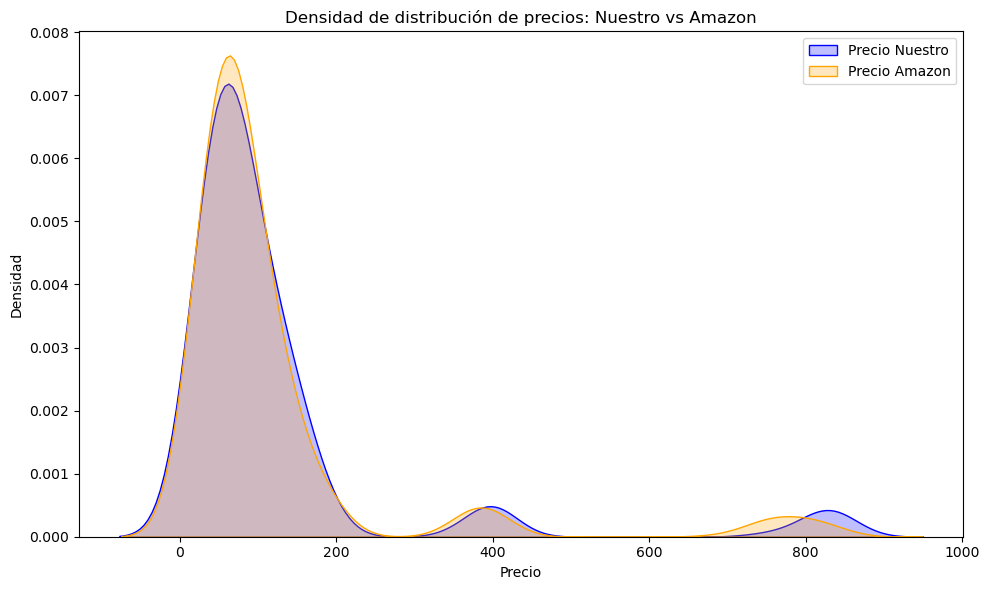

In [18]:
# 7. Gráfico de densidad de distribución de precios propios y de Amazon
plt.figure(figsize=(10, 6))
sns.kdeplot(df['precio_venta'], label='Precio Nuestro', fill=True, color='blue')
sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Densidad de distribución de precios: Nuestro vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Trabajar siempre sobre el DataFrame df que resulta del merge (con precios de competencia)
# Elimina la sobrescritura de df = ventas_df.copy() y usa df directamente

# Asegurarse de que la columna de fecha es datetime
if not np.issubdtype(df['fecha'].dtype, np.datetime64):
    df['fecha'] = pd.to_datetime(df['fecha'])

# Variables de calendario
spain_holidays = holidays.country_holidays('ES', years=range(df['fecha'].dt.year.min(), df['fecha'].dt.year.max()+1))

df['año'] = df['fecha'].dt.year
# Mes numérico y nombre
df['mes'] = df['fecha'].dt.month
# Día del mes
df['dia_mes'] = df['fecha'].dt.day
# Día de la semana (0=Lunes, 6=Domingo)
df['dia_semana'] = df['fecha'].dt.weekday
# Nombre del día de la semana
df['nombre_dia'] = df['fecha'].dt.day_name(locale='es_ES')
# Semana del año
df['semana_año'] = df['fecha'].dt.isocalendar().week
# Es fin de semana
df['es_fin_de_semana'] = df['dia_semana'].isin([5, 6])
# Es festivo nacional en España
df['es_festivo'] = df['fecha'].isin(spain_holidays)
# Es Black Friday (último viernes de noviembre)
df['es_black_friday'] = ((df['fecha'].dt.month == 11) & (df['fecha'].dt.weekday == 4) & (df['fecha'] + pd.offsets.Week(1)).dt.month == 12)
# Es Cyber Monday (primer lunes después de Black Friday)
black_fridays = df.loc[df['es_black_friday'], 'fecha']
cyber_mondays = black_fridays + pd.Timedelta(days=3)
df['es_cyber_monday'] = df['fecha'].isin(cyber_mondays)
# Día laborable (no fin de semana ni festivo)
df['es_laborable'] = (~df['es_fin_de_semana'] & ~df['es_festivo'])
# Día del año
df['dia_año'] = df['fecha'].dt.dayofyear
# Primer día del mes
df['es_primer_dia_mes'] = (df['dia_mes'] == 1)
# Último día del mes
df['es_ultimo_dia_mes'] = (df['fecha'] == df['fecha'] + pd.offsets.MonthEnd(0))
# Trimestre
df['trimestre'] = df['fecha'].dt.quarter
# Semestre
df['semestre'] = np.where(df['mes'] <= 6, 1, 2)

# Mostrar las primeras filas para verificar
(df.head())

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_fin_de_semana,es_festivo,es_black_friday,es_cyber_monday,es_laborable,dia_año,es_primer_dia_mes,es_ultimo_dia_mes,trimestre,semestre
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,False,False,True,298,False,False,4,2
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,False,False,False,False,True,298,False,False,4,2
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,False,False,False,False,True,298,False,False,4,2
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,False,False,True,298,False,False,4,2
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,False,False,True,298,False,False,4,2


In [20]:
# Creación de variables de lag y media móvil de 7 días por año, evitando mezcla entre años
# Suponiendo que la columna objetivo es 'unidades_vendidas' y el DataFrame es 'df' (el del merge)

# Ordenar por año y fecha por si acaso
df = df.sort_values(['año', 'fecha'])

# Crear lags y media móvil por año
for lag in range(1, 8):
    df[f'unidades_vendidas_lag_{lag}'] = df.groupby('año')['unidades_vendidas'].shift(lag)

df['unidades_vendidas_ma7'] = df.groupby('año')['unidades_vendidas'].transform(lambda x: x.rolling(window=7, min_periods=7).mean())

# Eliminar registros con nulos en alguna de las variables de lag o media móvil
lag_cols = [f'unidades_vendidas_lag_{i}' for i in range(1, 8)] + ['unidades_vendidas_ma7']
df = df.dropna(subset=lag_cols).reset_index(drop=True)

# Mostrar las primeras filas para verificar
print(df[['fecha', 'año', 'unidades_vendidas',
    'unidades_vendidas_lag_1', 'unidades_vendidas_lag_2', 'unidades_vendidas_lag_3',
    'unidades_vendidas_lag_4', 'unidades_vendidas_lag_5', 'unidades_vendidas_lag_6', 'unidades_vendidas_lag_7',
    'unidades_vendidas_ma7']].head(10))

       fecha   año  unidades_vendidas  unidades_vendidas_lag_1  \
0 2021-10-25  2021                  2                      2.0   
1 2021-10-25  2021                  2                      2.0   
2 2021-10-25  2021                  2                      2.0   
3 2021-10-25  2021                  3                      2.0   
4 2021-10-25  2021                  3                      3.0   
5 2021-10-25  2021                  2                      3.0   
6 2021-10-25  2021                  2                      2.0   
7 2021-10-25  2021                  3                      2.0   
8 2021-10-25  2021                  2                      3.0   
9 2021-10-25  2021                  1                      2.0   

   unidades_vendidas_lag_2  unidades_vendidas_lag_3  unidades_vendidas_lag_4  \
0                      2.0                      2.0                      2.0   
1                      2.0                      2.0                      2.0   
2                      2.0       

In [21]:
# Crear variable de descuento porcentual respecto al precio base
# Suponiendo que las columnas son 'precio_venta' y 'precio_base' en el df del merge
df['descuento_porcentaje'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

# Mostrar las primeras filas para verificar
print(df[['fecha', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10))

       fecha  precio_base  precio_venta  descuento_porcentaje
0 2021-10-25           65         66.60              2.461538
1 2021-10-25          400        392.31             -1.922500
2 2021-10-25          175        174.92             -0.045714
3 2021-10-25           45         44.32             -1.511111
4 2021-10-25           55         55.05              0.090909
5 2021-10-25           25         24.79             -0.840000
6 2021-10-25           40         39.74             -0.650000
7 2021-10-25          150        154.22              2.813333
8 2021-10-25          830        821.29             -1.049398
9 2021-10-25           95         96.56              1.642105


In [22]:
# Crear variable precio_competencia como el promedio de Amazon, Decathlon y Deporvillage
compet_cols = ['Amazon', 'Decathlon', 'Deporvillage']

df['precio_competencia'] = df[compet_cols].mean(axis=1)
# Crear variable ratio_precio (nuestro precio / precio competencia)
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']
# Eliminar las columnas de Amazon, Decathlon y Deporvillage
df = df.drop(columns=compet_cols)
# Mostrar las primeras filas para verificar
(df[['fecha', 'precio_venta', 'precio_competencia', 'ratio_precio']].head(10))

,fecha,precio_venta,precio_competencia,ratio_precio
0,2021-10-25,66.60,64.346667,1.035019
1,2021-10-25,392.31,350.850000,1.118170
2,2021-10-25,174.92,160.156667,1.092181
3,2021-10-25,44.32,44.563333,0.994540
4,2021-10-25,55.05,53.246667,1.033868
5,2021-10-25,24.79,24.096667,1.028773
6,2021-10-25,39.74,39.460000,1.007096
7,2021-10-25,154.22,135.673333,1.136701
8,2021-10-25,821.29,735.070000,1.117295
9,2021-10-25,96.56,92.636667,1.042352


In [23]:
# Crear copias de las variables categóricas con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding de las nuevas variables
cols_h = ['nombre_h', 'categoria_h', 'subcategoria_h']
df = pd.get_dummies(df, columns=cols_h, prefix=cols_h)

# Mostrar las primeras columnas para verificar
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-25,PROD_009,Bowflex SelectTech 552,Fitness,Mancuernas Ajustables,400,True,2,392.31,784.62,...,False,True,False,False,False,False,False,False,False,False
2,2021-10-25,PROD_010,Domyos BM900,Fitness,Banco Gimnasio,175,True,2,174.92,349.84,...,False,False,False,False,False,False,False,False,False,False
3,2021-10-25,PROD_011,Reebok Professional Deck,Fitness,Esterilla Fitness,45,False,3,44.32,132.96,...,False,False,False,False,False,False,False,False,False,False
4,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
# Guardar el DataFrame procesado en la carpeta processed
df.to_csv('../data/processed/df.csv', index=False)
print('Archivo guardado en ../data/processed/df.csv')

Archivo guardado en ../data/processed/df.csv


In [25]:
# Dividir df en train_df (2021-2023) y validation_df (2024)
train_df = df[df['fecha'].dt.year.isin([2021, 2022, 2023])]
validation_df = df[df['fecha'].dt.year == 2024]

print(f"Registros en train_df: {len(train_df)}")
print(f"Registros en validation_df: {len(validation_df)}")

Registros en train_df: 2643
Registros en validation_df: 881


In [28]:
# Entrenamiento y validación de HistGradientBoostingRegressor para forecasting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


# Selección de variables predictoras (excluyendo fecha, ingresos y tipo object)
exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols = [col for col in train_df.columns if col not in exclude_cols and not (train_df[col].dtype == 'O' or str(train_df[col].dtype).startswith('string'))]

y_train = train_df['unidades_vendidas']
X_train = train_df[X_cols].apply(pd.to_numeric, errors='coerce')
y_val = validation_df['unidades_vendidas']
X_val = validation_df[X_cols].apply(pd.to_numeric, errors='coerce')

# Eliminar columnas con valores no numéricos o nulos en los sets
cols_valid = X_train.columns[(X_train.dtypes != 'O') & (X_train.notnull().all()) & (X_val.notnull().all())]
X_train = X_train[cols_valid]
X_val = X_val[cols_valid]

# Modelo con parámetros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=6,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: predice la media del train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
mape_naive = mean_absolute_percentage_error(y_val, y_pred_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('--- Métricas HistGradientBoostingRegressor ---')
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2%}')
print(f'R2:   {r2:.2f}')
print('\n--- Métricas Baseline Naive (media) ---')
print(f'MAE:  {mae_naive:.2f}')
print(f'RMSE: {rmse_naive:.2f}')
print(f'MAPE: {mape_naive:.2%}')
print(f'R2:   {r2_naive:.2f}')

--- Métricas HistGradientBoostingRegressor ---
MAE:  0.72
RMSE: 1.51
MAPE: 16.44%
R2:   0.94

--- Métricas Baseline Naive (media) ---
MAE:  3.34
RMSE: 6.25
MAPE: 86.67%
R2:   -0.00


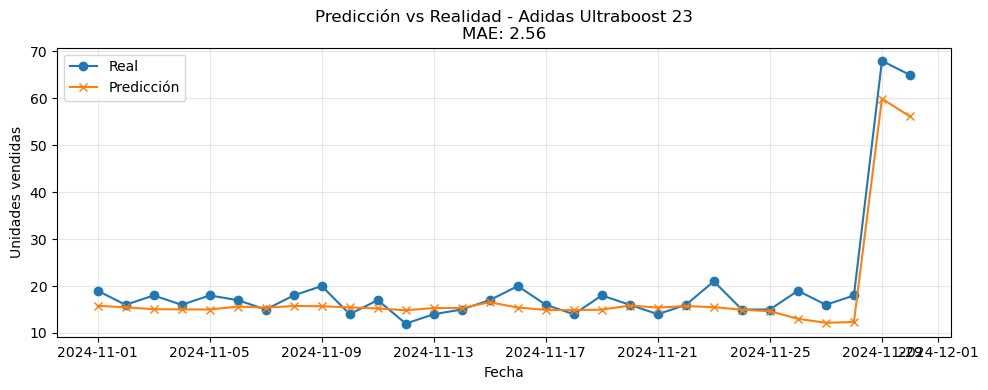

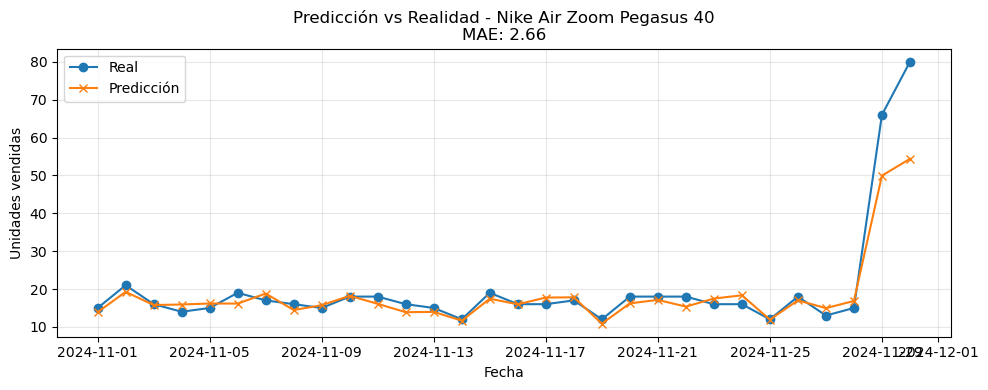

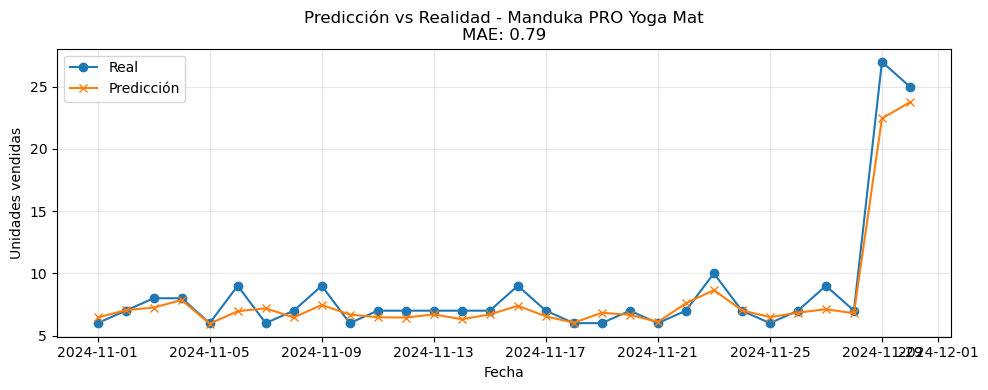

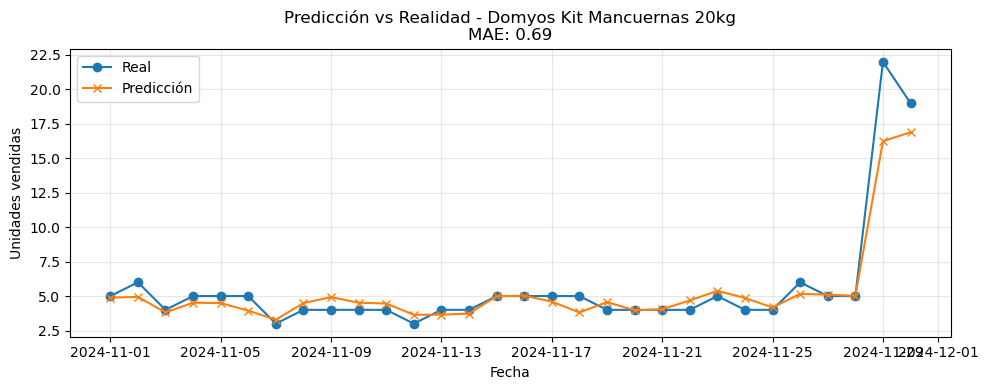

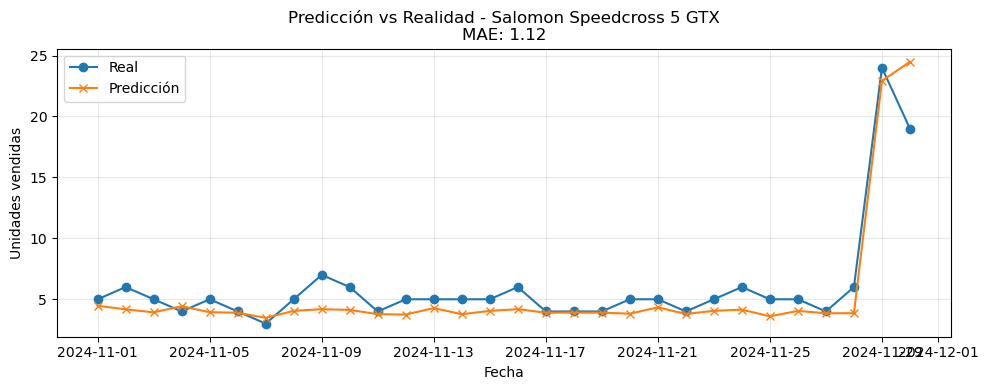

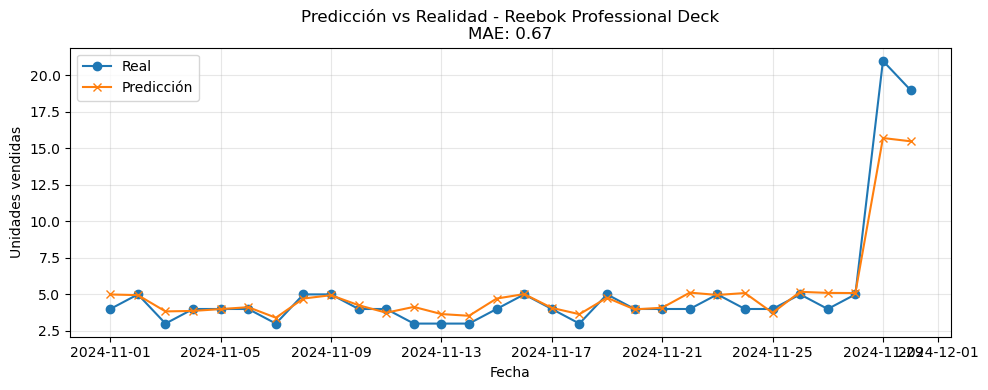

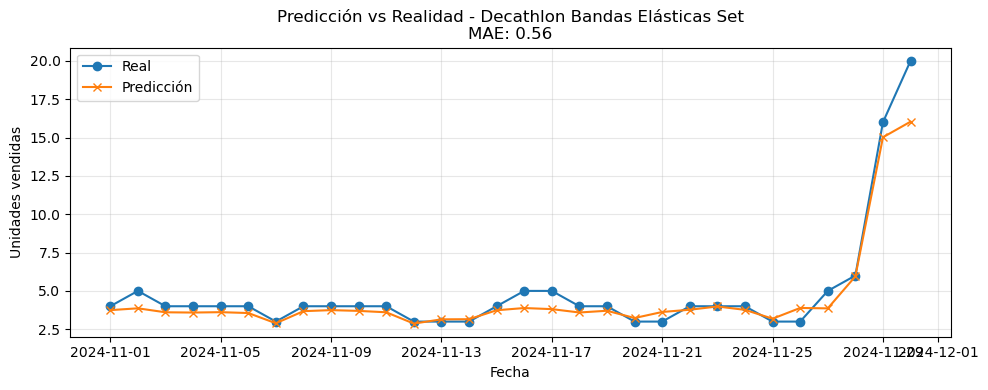

In [31]:
# Filtrar noviembre 2024
df_nov2024 = df[(df['fecha'] >= '2024-11-01') & (df['fecha'] <= '2024-11-30')].copy()

# Seleccionar los 7 productos estrella (por unidades vendidas históricas)
top7 = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(7).index.tolist()

from sklearn.metrics import mean_absolute_error
mae_por_producto = {}

# Predecir para cada producto estrella y graficar
for producto in top7:
    df_prod = df_nov2024[df_nov2024['nombre'] == producto].copy()
    if df_prod.empty:
        print(f"No hay datos de noviembre 2024 para: {producto}")
        continue
    # Preparar X para predicción (mismos features que el modelo)
    X_pred = df_prod[X_cols].apply(pd.to_numeric, errors='coerce')
    X_pred = X_pred[cols_valid]
    # Predicción
    df_prod['pred'] = model.predict(X_pred)
    # Calcular MAE
    mae = mean_absolute_error(df_prod['unidades_vendidas'], df_prod['pred'])
    mae_por_producto[producto] = mae
    # Gráfico
    plt.figure(figsize=(10, 4))
    plt.plot(df_prod['fecha'], df_prod['unidades_vendidas'], label='Real', marker='o')
    plt.plot(df_prod['fecha'], df_prod['pred'], label='Predicción', marker='x')
    plt.title(f'Predicción vs Realidad - {producto}\nMAE: {mae:.2f}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [32]:
# Mostrar MAE por producto estrella en noviembre 2024
def print_mae_por_producto(mae_por_producto, top7):
    print('MAE por producto estrella en noviembre 2024:')
    for producto in top7:
        if producto in mae_por_producto:
            print(f'{producto}: {mae_por_producto[producto]:.2f}')
        else:
            print(f'{producto}: Sin datos en noviembre 2024')

print_mae_por_producto(mae_por_producto, top7)

MAE por producto estrella en noviembre 2024:
Adidas Ultraboost 23: 2.56
Nike Air Zoom Pegasus 40: 2.66
Manduka PRO Yoga Mat: 0.79
Domyos Kit Mancuernas 20kg: 0.69
Salomon Speedcross 5 GTX: 1.12
Reebok Professional Deck: 0.67
Decathlon Bandas Elásticas Set: 0.56


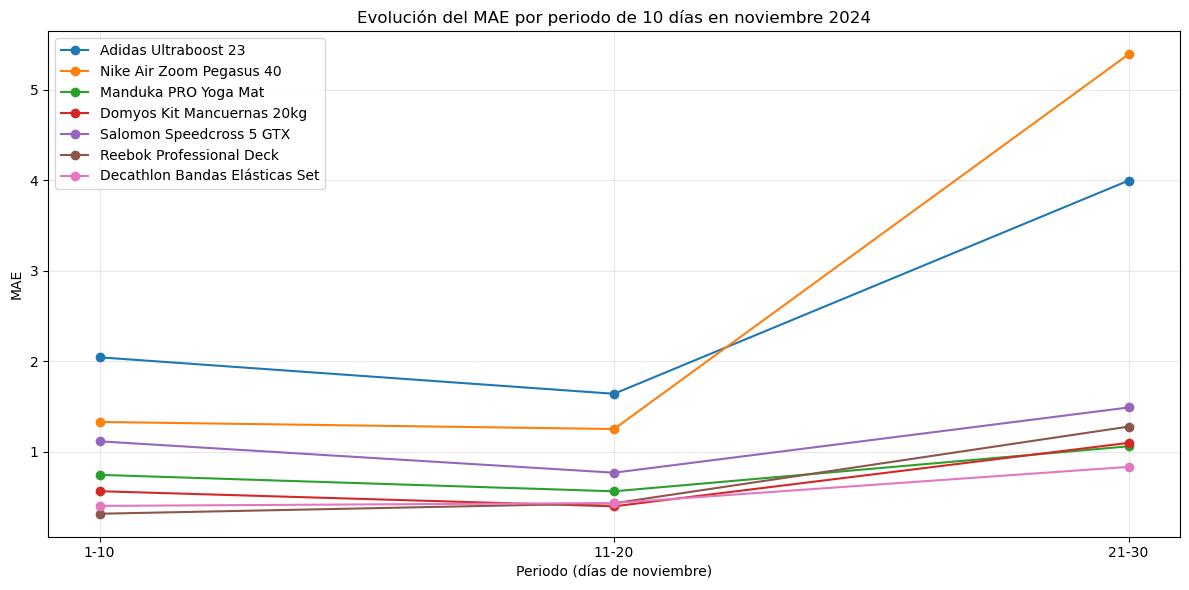

Métricas por periodo y producto:


,Producto,Periodo,MAE,RMSE
0,Adidas Ultraboost 23,1-10,2.042527,2.385488
1,Adidas Ultraboost 23,11-20,1.639494,2.128677
2,Adidas Ultraboost 23,21-30,3.995013,5.079437
3,Nike Air Zoom Pegasus 40,1-10,1.328396,1.536968
4,Nike Air Zoom Pegasus 40,11-20,1.250273,1.414116
5,Nike Air Zoom Pegasus 40,21-30,5.390130,9.685175
6,Manduka PRO Yoga Mat,1-10,0.743863,0.976373
7,Manduka PRO Yoga Mat,11-20,0.562152,0.694446
8,Manduka PRO Yoga Mat,21-30,1.059027,1.682125
9,Domyos Kit Mancuernas 20kg,1-10,0.563156,0.650981


In [38]:
# Analizar la degradación del error a lo largo de noviembre 2024 en 3 periodos de 10 días
# Crear periodos de 10 días
periodos = [(1, 10), (11, 20), (21, 30)]
periodos_labels = ["1-10", "11-20", "21-30"]

# DataFrame para almacenar métricas por periodo y producto
errores_periodo = []

for producto in top7:
    df_prod = df_nov2024[df_nov2024['nombre'] == producto].copy()
    # Si no existe la columna 'pred', recalcular predicción
    if df_prod.empty:
        continue
    if 'pred' not in df_prod.columns:
        X_pred = df_prod[X_cols].apply(pd.to_numeric, errors='coerce')
        X_pred = X_pred[cols_valid]
        df_prod['pred'] = model.predict(X_pred)
    df_prod['dia'] = df_prod['fecha'].dt.day
    for (start, end), label in zip(periodos, periodos_labels):
        df_per = df_prod[(df_prod['dia'] >= start) & (df_prod['dia'] <= end)]
        if df_per.empty:
            continue
        mae = mean_absolute_error(df_per['unidades_vendidas'], df_per['pred'])
        mse = mean_squared_error(df_per['unidades_vendidas'], df_per['pred'])
        rmse = np.sqrt(mse)
        errores_periodo.append({
            'Producto': producto,
            'Periodo': label,
            'MAE': mae,
            'RMSE': rmse
        })

# Convertir a DataFrame
errores_periodo_df = pd.DataFrame(errores_periodo)

# Graficar evolución del MAE por periodo para cada producto
plt.figure(figsize=(12, 6))
for producto in top7:
    df_plot = errores_periodo_df[errores_periodo_df['Producto'] == producto]
    if not df_plot.empty:
        plt.plot(df_plot['Periodo'], df_plot['MAE'], marker='o', label=producto)
plt.title('Evolución del MAE por periodo de 10 días en noviembre 2024')
plt.xlabel('Periodo (días de noviembre)')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabla de métricas
print('Métricas por periodo y producto:')
display(errores_periodo_df)


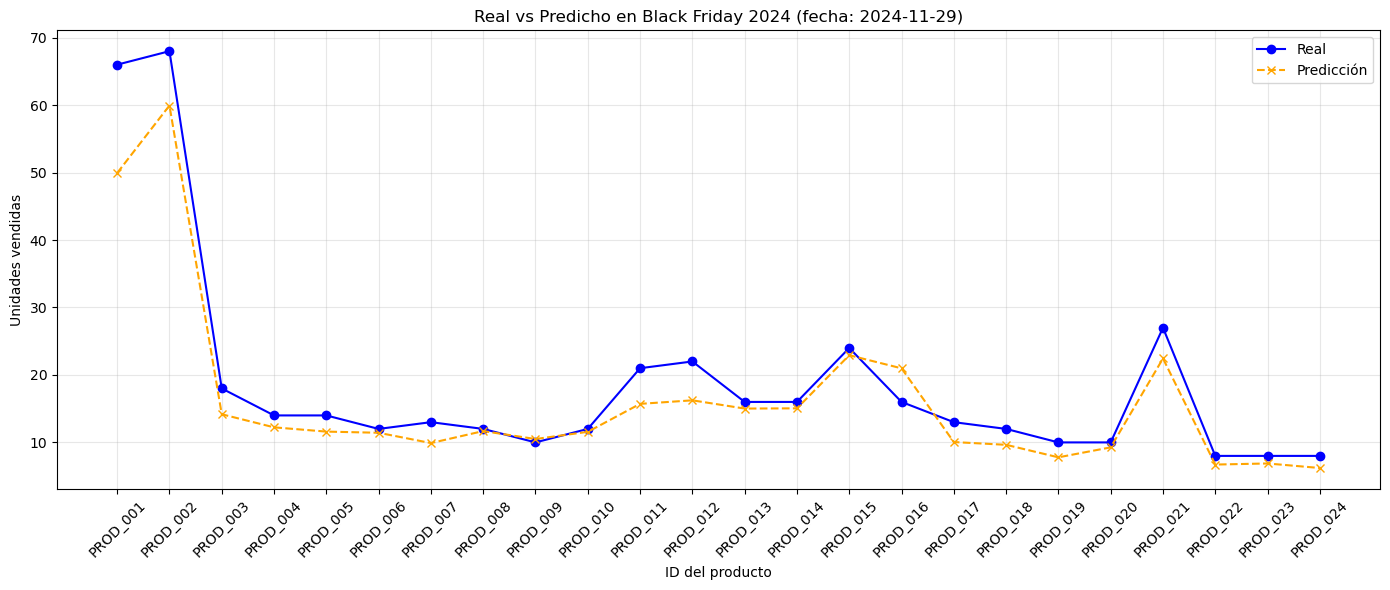

Resumen Black Friday 2024:


,producto_id,nombre,unidades_vendidas,pred
3476,PROD_001,Nike Air Zoom Pegasus 40,66,49.935526
3477,PROD_002,Adidas Ultraboost 23,68,59.944059
3478,PROD_003,Asics Gel Nimbus 25,18,14.172069
3479,PROD_004,New Balance Fresh Foam X 1080v12,14,12.234291
3480,PROD_005,Nike Dri-FIT Miler,14,11.601026
3481,PROD_006,Adidas Own The Run Jacket,12,11.430424
3482,PROD_007,Puma Velocity Nitro 2,13,9.902967
3483,PROD_008,Reebok Floatride Energy 5,12,11.679707
3484,PROD_009,Bowflex SelectTech 552,10,10.502197
3485,PROD_010,Domyos BM900,12,11.568177


In [43]:
# Analizar Black Friday 2024: comparación real vs predicho para todos los productos
import matplotlib.pyplot as plt
import numpy as np

# Identificar la fecha de Black Friday 2024 (último viernes de noviembre)
noviembre_2024 = pd.date_range(start='2024-11-01', end='2024-11-30', freq='D')
black_friday_2024 = noviembre_2024[noviembre_2024.weekday == 4][-1]

# Filtrar datos de Black Friday 2024
bf_df = df_nov2024[df_nov2024['fecha'] == black_friday_2024].copy()

# Si no existe la columna 'pred', calcularla para todos los productos
if 'pred' not in bf_df.columns:
    X_pred = bf_df[X_cols].apply(pd.to_numeric, errors='coerce')
    X_pred = X_pred[cols_valid]
    bf_df['pred'] = model.predict(X_pred)

# Ordenar por producto_id para el eje X
bf_df = bf_df.sort_values('producto_id')

plt.figure(figsize=(14, 6))
plt.plot(bf_df['producto_id'], bf_df['unidades_vendidas'], label='Real', marker='o', linestyle='-', color='blue')
plt.plot(bf_df['producto_id'], bf_df['pred'], label='Predicción', marker='x', linestyle='--', color='orange')
plt.title(f'Real vs Predicho en Black Friday 2024 (fecha: {black_friday_2024.date()})')
plt.xlabel('ID del producto')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostrar tabla resumen de valores reales y predichos
print('Resumen Black Friday 2024:')
display(bf_df[['producto_id', 'nombre', 'unidades_vendidas', 'pred']])


In [44]:
# Reentrenar modelo final con todos los datos históricos (2021-2024)
from sklearn.ensemble import HistGradientBoostingRegressor

# Seleccionar variables predictoras (mismas que antes)
exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
X_cols_final = [col for col in df.columns if col not in exclude_cols and not (df[col].dtype == 'O' or str(df[col].dtype).startswith('string'))]

# Preparar X e y para todo el periodo 2021-2024
X_full = df[X_cols_final].apply(pd.to_numeric, errors='coerce')
y_full = df['unidades_vendidas']

# Eliminar columnas con valores no numéricos o nulos en todo el set
cols_valid_final = X_full.columns[(X_full.dtypes != 'O') & (X_full.notnull().all())]
X_full = X_full[cols_valid_final]

# Entrenar el modelo final
modelo_final = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=400,
    max_depth=6,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
modelo_final.fit(X_full, y_full)

print('Modelo final entrenado con todos los datos históricos (2021-2024).')


Modelo final entrenado con todos los datos históricos (2021-2024).


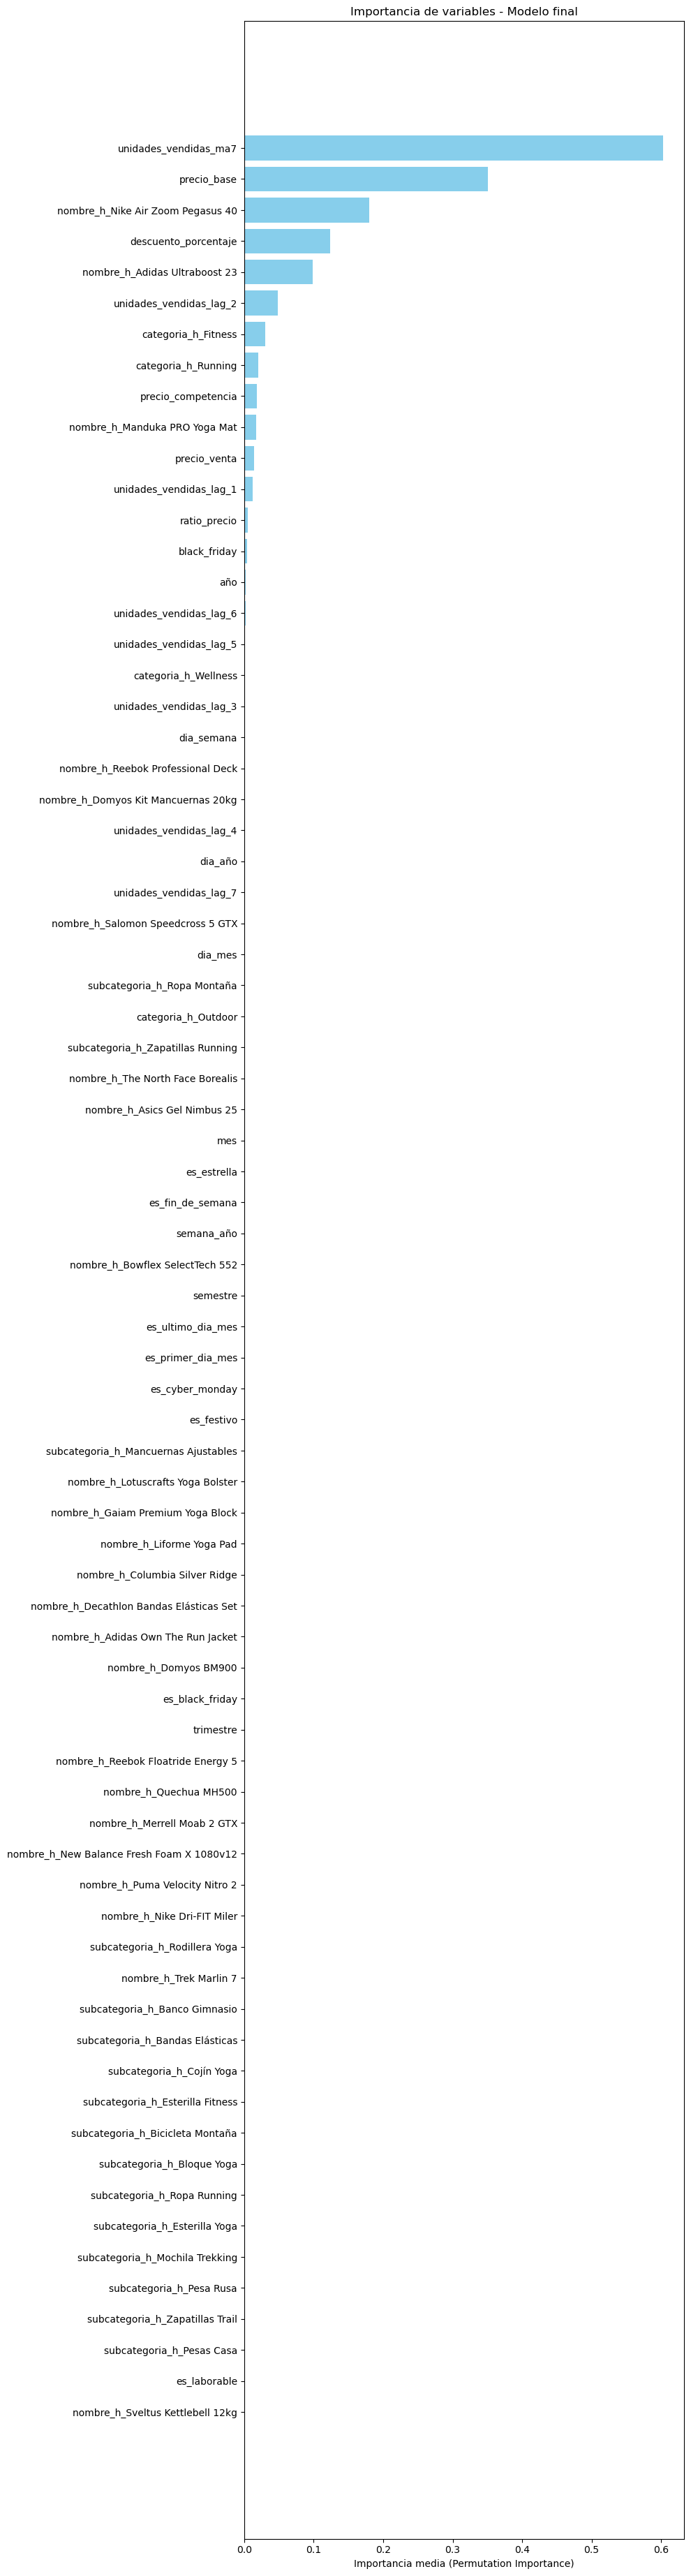

Modelo final guardado en ../models/modelo_Final.joblib


In [45]:
# Importancia de variables con Permutation Importance y guardado del modelo final
from sklearn.inspection import permutation_importance
import joblib
import os

# Calcular Permutation Importance sobre el set completo (X_full, y_full)
result = permutation_importance(
    modelo_final, X_full, y_full, n_repeats=10, random_state=42, n_jobs=-1
)

# Crear DataFrame de importancias
importancias = pd.DataFrame({
    'variable': X_full.columns,
    'importancia': result.importances_mean
})
importancias = importancias.sort_values('importancia', ascending=False)

# Gráfico de barras horizontales
plt.figure(figsize=(10, max(6, len(importancias) // 2)))
plt.barh(importancias['variable'], importancias['importancia'], color='skyblue')
plt.xlabel('Importancia media (Permutation Importance)')
plt.title('Importancia de variables - Modelo final')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final en la carpeta models
os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_final, '../models/modelo_Final.joblib')
print('Modelo final guardado en ../models/modelo_Final.joblib')
